In [37]:
import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [38]:
cdr = pd.read_csv('cdr_sample.csv')
towers = pd.read_csv('celltower_location.csv')

d = cdr['date'].astype(str).str.zfill(6)
cdr['date'] = pd.to_datetime('20' + d.str[:2] + '-' + d.str[2:4] + '-' + d.str[4:6])

cdr['hour'] = pd.to_datetime(cdr['time'], format='%H:%M:%S').dt.hour
cdr['night_weight'] = cdr['hour'].apply(lambda h: 2 if (h >= 20 or h < 8) else 1)

tower_to_district = dict(zip(towers['antenna_id'], towers['district']))

sampled_users = set(cdr['user_1'].unique())

# User
loc1 = cdr[['user_1', 'date', 'tower_1', 'night_weight']].copy()
loc1.columns = ['user_id', 'date', 'tower', 'night_weight']
loc1['district'] = loc1['tower'].map(tower_to_district)

loc2 = cdr[['user_2', 'date', 'tower_2', 'night_weight']].copy()
loc2.columns = ['user_id', 'date', 'tower', 'night_weight']
loc2['district'] = loc2['tower'].map(tower_to_district)

# combine
cdr_clean = pd.concat([loc1, loc2], ignore_index=True)
cdr_clean = cdr_clean.dropna(subset=['district'])
cdr_clean = cdr_clean[cdr_clean['user_id'].isin(sampled_users)]
cdr_clean = cdr_clean[['user_id', 'date', 'district', 'night_weight']]

print(cdr_clean.head())
print(cdr_clean['user_id'].nunique())

     user_id       date    district  night_weight
0  L55737047 2008-06-17      Rusizi             1
1  L55737047 2008-07-30  Nyamasheke             2
2  L55737047 2008-04-22  Nyamasheke             1
3  L55737047 2008-04-08      Rusizi             1
4  L55737047 2008-01-23      Rusizi             1
3610


In [39]:
print(cdr_clean.columns.tolist())
print(cdr_clean.head(2))

['user_id', 'date', 'district', 'night_weight']
     user_id       date    district  night_weight
0  L55737047 2008-06-17      Rusizi             1
1  L55737047 2008-07-30  Nyamasheke             2


In [40]:
all_dates = pd.date_range(cdr_clean['date'].min(), cdr_clean['date'].max(), freq='D')
date2idx = {}
for i, d in enumerate(all_dates):
    date2idx[pd.Timestamp(d)] = i
idx2date = {i: d for d, i in date2idx.items()}

cdr_clean['date_idx'] = cdr_clean['date'].map(date2idx)

user_daily = defaultdict(lambda: defaultdict(lambda: defaultdict(float)))
for row in cdr_clean.itertuples(index=False):
    user_daily[row.user_id][row.date_idx][row.district] += getattr(row, 'night_weight')

print(f" {len(user_daily)}")

 3610


In [41]:
def fill_missing_day(daily_dict, epsilon=7):

    if not daily_dict:
        return {}
    filled = dict(daily_dict)
    days = sorted(daily_dict.keys())
    for i in range(len(days) - 1):
        gap = days[i+1] - days[i] - 1
        if 0 < gap <= epsilon:
            for d in range(days[i] + 1, days[i+1]):
                filled[d] = daily_dict[days[i]]
    return filled

In [42]:
def find_segments(filled_dict, min_days=30):
    if not filled_dict:
        return {}

    district_days = defaultdict(list)
    for day, dist_weights in filled_dict.items():
        for dist in dist_weights:
            district_days[dist].append(day)

    segments = {}
    for district, days in district_days.items():
        days = sorted(days)
        segs = []
        seg_start = days[0]
        seg_end = days[0]
        for day in days[1:]:
            if day == seg_end + 1:
                seg_end = day
            else:
                if seg_end - seg_start + 1 >= min_days:
                    segs.append((seg_start, seg_end))
                seg_start = day
                seg_end = day
        if seg_end - seg_start + 1 >= min_days:
            segs.append((seg_start, seg_end))
        if segs:
            segments[district] = segs
    return segments


In [43]:
def filter_seg_by_prop(raw_daily, segments, prop=0.6):
    filtered = {}
    for district, segs in segments.items():
        valid_segs = []
        for (start, end) in segs:
            length = end - start + 1
            actual_weight = sum(
                raw_daily[day][district]
                for day in range(start, end + 1)
                if day in raw_daily and district in raw_daily[day]
            )
            if actual_weight >= prop * length:
                valid_segs.append((start, end))
        if valid_segs:
            filtered[district] = valid_segs
    return filtered

In [44]:
def merge_segments(segments):
    if not segments:
        return {}
    
    merged = {}
    for district, segs in segments.items():
        segs = sorted(segs, key=lambda x: x[0])
        result = [segs[0]]
        for seg in segs[1:]:
            prev = result[-1]
            
            gap_start = prev[1] + 1
            gap_end = seg[0] - 1
            has_other = False
            for other_d, other_segs in segments.items():
                if other_d == district:
                    continue
                for (os, oe) in other_segs:
                   
                    if os <= gap_end and oe >= gap_start:
                        has_other = True
                        break
                if has_other:
                    break
            if not has_other:
                result[-1] = (prev[0], max(prev[1], seg[1]))
            else:
                result.append(seg)
        merged[district] = result
    return merged


In [45]:
def remove_overlap_and_filter(segments, k=90):
    all_segs = []
    for district, segs in segments.items():
        for (s, e) in segs:
            all_segs.append((s, e, district, e - s + 1))
    
    if not all_segs:
        return {}
    
    all_segs.sort(key=lambda x: -x[3])
    

    day_owner = {}
    for (s, e, district, length) in all_segs:
        for day in range(s, e + 1):
            if day not in day_owner:
                day_owner[day] = district

    if not day_owner:
        return {}
    
    days_sorted = sorted(day_owner.keys())
    result = defaultdict(list)
    seg_start = days_sorted[0]
    seg_dist = day_owner[days_sorted[0]]
    
    for day in days_sorted[1:]:
        current_dist = day_owner[day]
        if day == days_sorted[days_sorted.index(day) - 1] + 1 and current_dist == seg_dist:
            pass  
        else:
            length = day - 1 - seg_start + 1  
            if length >= k:
                result[seg_dist].append((seg_start, day - 1))
            seg_start = day
            seg_dist = current_dist
    

    last_day = days_sorted[-1]
    length = last_day - seg_start + 1
    if length >= k:
        result[seg_dist].append((seg_start, last_day))
    
    return dict(result)



In [46]:
def remove_overlap_and_filter_v2(segments, k=90):
   
    all_segs = []
    for district, segs in segments.items():
        for (s, e) in segs:
            all_segs.append((s, e, district, e - s + 1))
    
    if not all_segs:
        return {}
    
    all_segs.sort(key=lambda x: -x[3])
    
    day_owner = {}
    for (s, e, district, _) in all_segs:
        for day in range(s, e + 1):
            if day not in day_owner:
                day_owner[day] = district
    
    if not day_owner:
        return {}
    
    days_sorted = sorted(day_owner.keys())
    result = defaultdict(list)
    
    seg_start = days_sorted[0]
    seg_dist = day_owner[days_sorted[0]]
    prev_day = days_sorted[0]
    
    for day in days_sorted[1:]:
        current_dist = day_owner[day]
        if day == prev_day + 1 and current_dist == seg_dist:
            prev_day = day
        else:
            length = prev_day - seg_start + 1
            if length >= k:
                result[seg_dist].append((seg_start, prev_day))
            seg_start = day
            seg_dist = current_dist
            prev_day = day
    
    length = prev_day - seg_start + 1
    if length >= k:
        result[seg_dist].append((seg_start, prev_day))
    
    return dict(result)



In [47]:
def find_migrations(long_segments):
    
    all_segs = []
    for district, segs in long_segments.items():
        for (s, e) in segs:
            all_segs.append((s, e, district))
    
    all_segs.sort(key=lambda x: x[0])
    
    migrations = []
    for i in range(len(all_segs) - 1):
        s1, e1, d1 = all_segs[i]
        s2, e2, d2 = all_segs[i+1]
        if d1 != d2:
            migrations.append((d1, s1, e1, d2, s2, e2))
    return migrations


In [48]:
def find_migration_date(home_end, dest_start, raw_daily, home_dist, dest_dist):

    if dest_start <= home_end:
        # 有重叠，在重叠区间内找最优分割点
        overlap_start = dest_start
        overlap_end = home_end
        best_t = overlap_start
        best_errors = float('inf')
        
        for t in range(overlap_start, overlap_end + 2):
            errors = 0
            for day in range(overlap_start, overlap_end + 1):
                if day in raw_daily:
                    if day < t and dest_dist in raw_daily[day]:
                        errors += 1
                    if day >= t and home_dist in raw_daily[day]:
                        errors += 1
            if errors <= best_errors:
                best_errors = errors
                best_t = t
        uncertainty = 0
    else:
    
        best_t = (home_end + dest_start) // 2
        uncertainty = dest_start - home_end - 1
    
    return best_t, uncertainty


In [49]:
import numpy as np

if len(segments_df) == 0:
   
else:
    lengths = segments_df['length_days'].values


    for q in [0.25, 0.50, 0.75, 0.90, 0.95]:
        print(f"p{int(q*100)} =", np.quantile(lengths, q))

IndentationError: expected an indented block after 'if' statement on line 3 (2934964746.py, line 5)

In [ ]:

MIN_DAYS = 30
PROP_DAYS = 0.5
K = 60
EPSILON = 7
MAX_GAP = 30
print(f" ε={EPSILON}, minDays={MIN_DAYS}, propDays={PROP_DAYS}, k={K}")

all_migrations = []
users = list(user_daily.keys())
data_end_idx = max(idx2date.keys())  

for i, user_id in enumerate(users):
    if i % 500 == 0:
        print(f" {i}/{len(users)}")

    raw_daily = user_daily[user_id]

    filled = fill_missing_day(raw_daily, epsilon=EPSILON)

    segs = find_segments(filled, min_days=MIN_DAYS)

    segs = filter_seg_by_prop(raw_daily, segs, prop=PROP_DAYS)

    segs = merge_segments(segs)

    long_segs = remove_overlap_and_filter_v2(segs, k=K)

    if len(long_segs) < 2:
        continue

    migrations = find_migrations(long_segs)

    for (home_d, home_s, home_e, dest_d, dest_s, dest_e) in migrations:
        gap = dest_s - home_e - 1
        if gap > MAX_GAP:
            continue

        mig_day, uncertainty = find_migration_date(
            home_e, dest_s, raw_daily, home_d, dest_d
        )

        is_return = (data_end_idx - dest_e) >= K

        all_migrations.append({
            'user_id': user_id,
            'home': home_d,
            'destination': dest_d,
            'home_start': idx2date[home_s],
            'home_end': idx2date[home_e],
            'destination_start': idx2date[dest_s],
            'destination_end': idx2date[dest_e],
            'migration_date': idx2date[mig_day],
            'uncertainty_days': uncertainty,
            'gap_days': gap,
            'is_return': is_return
        })

migrants_df = pd.DataFrame(all_migrations)
print(f"\nmigrants_df：{len(migrants_df)} ")
print(f"user_id：{migrants_df['user_id'].nunique() if len(migrants_df) > 0 else 0}")

permanent = migrants_df[migrants_df['is_return'] == False]
temporary = migrants_df[migrants_df['is_return'] == True]
print(f"\npermanent: {len(permanent)} ")
print(f"temporary: {len(temporary)} ")
print(migrants_df.head())

 ε=7, minDays=30, propDays=0.5, k=60
 0/3610


NameError: name 'fill_missing_day' is not defined

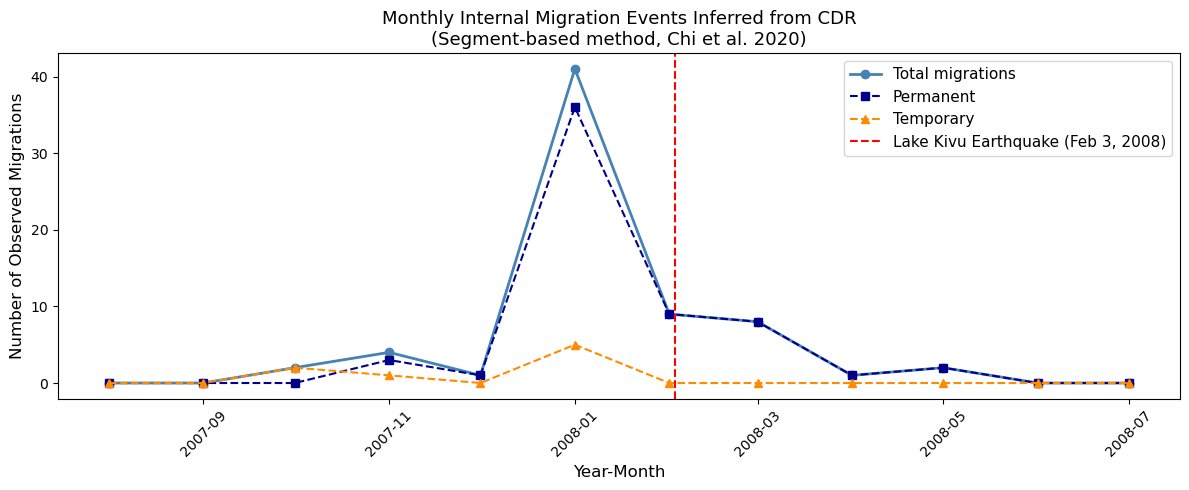

In [ ]:
migrants_df['mig_month2'] = pd.to_datetime(
    migrants_df['migration_date']
).dt.to_period('M')

full_months = pd.period_range(
    cdr_clean['date'].min(),
    cdr_clean['date'].max(),
    freq='M'
)

perm_df = migrants_df[migrants_df['is_return'] == False]
temp_df = migrants_df[migrants_df['is_return'] == True]

perm_counts = perm_df.groupby('mig_month2').size().reindex(full_months, fill_value=0)
temp_counts = temp_df.groupby('mig_month2').size().reindex(full_months, fill_value=0)
total_counts = migrants_df.groupby('mig_month2').size().reindex(full_months, fill_value=0)

month_dt = [p.to_timestamp() for p in full_months]

# plot
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(month_dt, total_counts.values,
        marker='o', linewidth=2, color='steelblue', label='Total migrations')
ax.plot(month_dt, perm_counts.values,
        marker='s', linewidth=1.5, linestyle='--', color='darkblue', label='Permanent')
ax.plot(month_dt, temp_counts.values,
        marker='^', linewidth=1.5, linestyle='--', color='darkorange', label='Temporary')

ax.axvline(x=pd.Timestamp('2008-02-03'), color='red', linestyle='--',
           linewidth=1.5, label='Lake Kivu Earthquake (Feb 3, 2008)')

ax.set_xlabel('Year-Month', fontsize=12)
ax.set_ylabel('Number of Observed Migrations', fontsize=12)
ax.set_title('Monthly Internal Migration Events Inferred from CDR\n(Segment-based method, Chi et al. 2020)',
             fontsize=13)
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('migration_timeseries.png', dpi=150)
plt.show()

In [ ]:
earthquake_date = pd.Timestamp('2008-02-03')
affected_districts = ['Rusizi', 'Nyamasheke']

df_all = migrants_df.copy()
df_affected = df_all[df_all['home'].isin(affected_districts)].copy()

full_months = pd.period_range(
    cdr_clean['date'].min(),
    cdr_clean['date'].max(),
    freq='M'
)

# all
all_total   = df_all.groupby('mig_month2').size().reindex(full_months, fill_value=0)
all_perm    = df_all[df_all['is_return']==False].groupby('mig_month2').size().reindex(full_months, fill_value=0)
all_temp    = df_all[df_all['is_return']==True].groupby('mig_month2').size().reindex(full_months, fill_value=0)

# affected
aff_total   = df_affected.groupby('mig_month2').size().reindex(full_months, fill_value=0)
aff_perm    = df_affected[df_affected['is_return']==False].groupby('mig_month2').size().reindex(full_months, fill_value=0)
aff_temp    = df_affected[df_affected['is_return']==True].groupby('mig_month2').size().reindex(full_months, fill_value=0)

month_dt = [p.to_timestamp() for p in full_months]

# pre
pre_mask = [t < earthquake_date for t in month_dt]
baseline = aff_total.values[pre_mask].mean()

# plot
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

# for all
axes[0].plot(month_dt, all_total.values,
             marker='o', color='steelblue', linewidth=2, label='Total')
axes[0].plot(month_dt, all_perm.values,
             marker='s', linestyle='--', color='darkblue', linewidth=1.5, label='Permanent')
axes[0].plot(month_dt, all_temp.values,
             marker='^', linestyle='--', color='darkorange', linewidth=1.5, label='Temporary')
axes[0].axvline(earthquake_date, color='red', linestyle='--',
                linewidth=1.5, label='Earthquake (Feb 3, 2008)')
axes[0].set_ylabel('Number of Migrations')
axes[0].set_title('Monthly Migrations — All Users')
axes[0].legend()

# for affected
axes[1].plot(month_dt, aff_total.values,
             marker='o', color='steelblue', linewidth=2, label='Total')
axes[1].plot(month_dt, aff_perm.values,
             marker='s', linestyle='--', color='darkblue', linewidth=1.5, label='Permanent')
axes[1].plot(month_dt, aff_temp.values,
             marker='^', linestyle='--', color='darkorange', linewidth=1.5, label='Temporary')
axes[1].axvline(earthquake_date, color='red', linestyle='--',
                linewidth=1.5, label='Earthquake (Feb 3, 2008)')
axes[1].axhline(baseline, color='gray', linestyle=':', linewidth=1.5,
                label=f'Pre-earthquake average ({baseline:.1f})')
axes[1].set_ylabel('Number of Migrations')
axes[1].set_title('Monthly Out-Migrations from Earthquake-Affected Districts (Rusizi & Nyamasheke)')
axes[1].legend()

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('earthquake_migration.png', dpi=150)
plt.show()

NameError: name 'migrants_df' is not defined

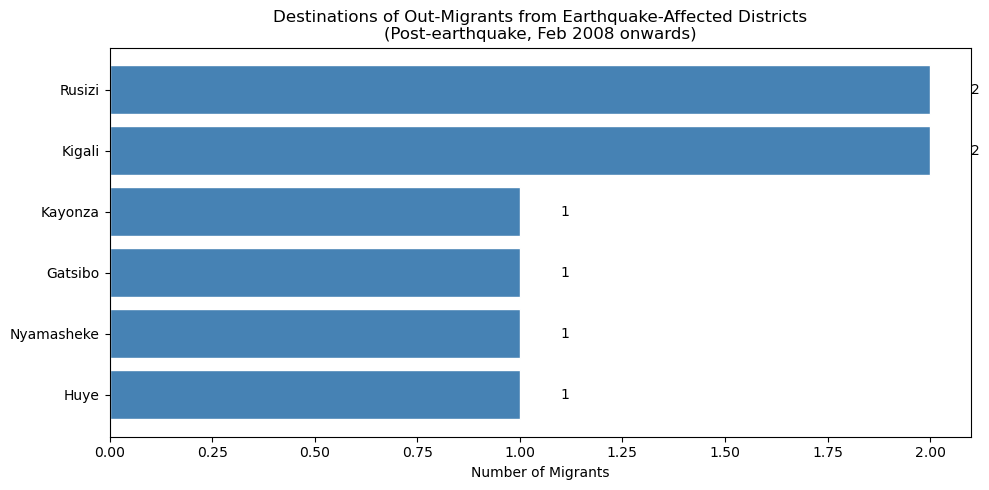

  destination  count
0      Rusizi      2
1      Kigali      2
2     Kayonza      1
3     Gatsibo      1
4  Nyamasheke      1
5        Huye      1


In [ ]:
post_eq_affected = migrants_df[
    (migrants_df['home'].isin(affected_districts)) &
    (pd.to_datetime(migrants_df['home_end']) >= earthquake_date)
]

dest_counts = post_eq_affected['destination'].value_counts().reset_index()
dest_counts.columns = ['destination', 'count']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(dest_counts['destination'], dest_counts['count'],
               color='steelblue', edgecolor='white')
ax.set_xlabel('Number of Migrants')
ax.set_title('Destinations of Out-Migrants from Earthquake-Affected Districts\n(Post-earthquake, Feb 2008 onwards)')
ax.invert_yaxis()

for bar, count in zip(bars, dest_counts['count']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(count), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('destinations.png', dpi=150)
plt.show()

print(dest_counts)

In [ ]:
post_eq_affected = post_eq_affected.copy()
post_eq_affected['dest_duration_days'] = (
    pd.to_datetime(post_eq_affected['destination_end']) -
    pd.to_datetime(post_eq_affected['destination_start'])
).dt.days

print(post_eq_affected['dest_duration_days'].describe().round(1))

# distribution
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(post_eq_affected['dest_duration_days'], bins=15,
        color='steelblue', edgecolor='white')
ax.set_xlabel('Days Spent at Destination')
ax.set_ylabel('Number of Migrants')
ax.set_title('Duration of Stay at Destination\n(Post-earthquake out-migrants from affected districts)')
plt.tight_layout()
plt.savefig('duration.png', dpi=150)
plt.show()

NameError: name 'post_eq_affected' is not defined

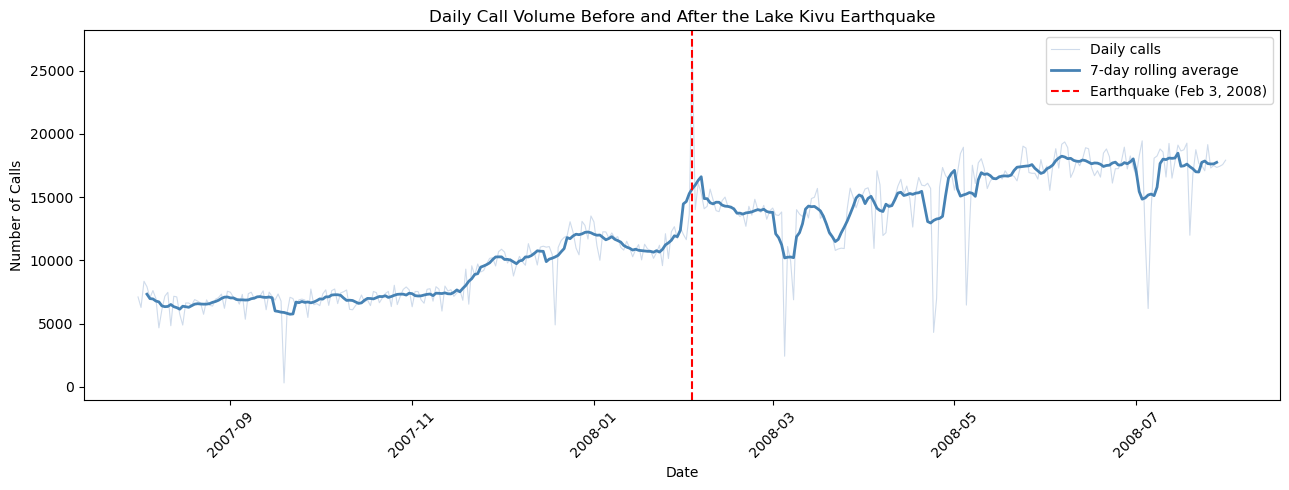

In [50]:
cdr['call_date'] = cdr['date'] 

daily_calls = cdr.groupby('call_date').size().reset_index(name='n_calls')
daily_calls = daily_calls.sort_values('call_date')

daily_calls['rolling_avg'] = daily_calls['n_calls'].rolling(window=7, center=True).mean()

#plot
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(daily_calls['call_date'], daily_calls['n_calls'],
        color='lightsteelblue', linewidth=0.8, alpha=0.6, label='Daily calls')
ax.plot(daily_calls['call_date'], daily_calls['rolling_avg'],
        color='steelblue', linewidth=2, label='7-day rolling average')
ax.axvline(earthquake_date, color='red', linestyle='--',
           linewidth=1.5, label='Earthquake (Feb 3, 2008)')

ax.set_xlabel('Date')
ax.set_ylabel('Number of Calls')
ax.set_title('Daily Call Volume Before and After the Lake Kivu Earthquake')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('call_volume.png', dpi=150)
plt.show()